In [1]:
pip install -U bitsandbytes>=0.46.1

In [2]:
pip -q install -U bitsandbytes accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 10.0 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os, glob, warnings, re, json as pyjson
import numpy as np
import pandas as pd
warnings.filterwarnings('ignore')

# ---- EDIT THIS if different: same BASE_DIR used in Notebooks 1-3 ----
BASE_DIR = '/content/drive/MyDrive/My Work/Research/Medical_sector/Dengue/dataset'
# -----------------------------------------------------------------------

def find_file(base_dir, filename):
    matches = glob.glob(os.path.join(base_dir, '**', filename), recursive=True)
    return matches[0] if matches else None

OUTPUT_DIR = os.path.join(BASE_DIR, 'processed')
FIG_DIR    = os.path.join(BASE_DIR, 'figures')

evidence_path      = find_file(OUTPUT_DIR, 'forecast_evidence_for_llm.csv')
nb3_eval_path       = find_file(OUTPUT_DIR, 'llm_explanations_evaluated.csv')

assert evidence_path, 'Could not find Notebook 2 output (forecast_evidence_for_llm.csv). Run Notebook 2 first.'
assert nb3_eval_path, 'Could not find Notebook 3 output (llm_explanations_evaluated.csv). Run Notebook 3 first.'

evidence_df = pd.read_csv(evidence_path, parse_dates=['target_week'])
nb3_eval_df = pd.read_csv(nb3_eval_path)
nb3_eval_df['hallucinated_values'] = nb3_eval_df['hallucinated_values'].apply(pyjson.loads)

print('Evidence rows available:', len(evidence_df))
print('Notebook 3 pilot generations loaded:', len(nb3_eval_df), '(', nb3_eval_df['model'].nunique(), 'models )')
print(nb3_eval_df.groupby('model').size())

Evidence rows available: 64
Notebook 3 pilot generations loaded: 36 ( 3 models )
model
NousResearch/Meta-Llama-3.1-8B-Instruct    12
Qwen/Qwen2.5-3B-Instruct                   12
Qwen/Qwen2.5-7B-Instruct                   12
dtype: int64


## 1. Feature vocabulary (same as Notebook 3)

Reproduced here (not re-imported) so this notebook is self-contained and does not require re-running Notebook 3.

In [5]:
FEATURE_INFO = {
    'cases_lag1':  ('dengue cases reported in the most recent week', ['recent case', 'last week', 'past week', 'current case']),
    'cases_lag2':  ('dengue cases from 2 weeks ago', ['2 week', 'two week', 'recent case']),
    'cases_lag4':  ('dengue cases from 4 weeks ago', ['4 week', 'four week', 'recent case', 'past month']),
    'cases_lag8':  ('dengue cases from 8 weeks ago', ['8 week', 'eight week', 'past case']),
    'cases_lag12': ('dengue cases from 12 weeks ago', ['12 week', 'twelve week']),
    'rain_roll4':  ('recent 4-week average rainfall', ['rain', 'rainfall', 'precipitation', 'monsoon']),
    'temp_roll4':  ('recent 4-week average temperature', ['temperature', 'warm', 'heat']),
    'humidity_roll4': ('recent 4-week average humidity', ['humidity', 'humid']),
    'week_sin': ('seasonal time-of-year pattern', ['season', 'time of year', 'monsoon', 'seasonal']),
    'week_cos': ('seasonal time-of-year pattern', ['season', 'time of year', 'monsoon', 'seasonal']),
    'is_eid_window': ('proximity to an Eid holiday (mass travel period)', ['eid', 'holiday', 'travel', 'migration']),
    'days_to_nearest_eid': ('proximity to an Eid holiday (mass travel period)', ['eid', 'holiday', 'travel']),
    'is_outbreak_year_2023': ('the 2023 outbreak-year effect', ['2023', 'outbreak year', 'record year']),
    'avg_temp': ('average temperature', ['temperature', 'warm', 'heat']),
    'avg_humidity': ('average humidity', ['humidity', 'humid']),
    'total_rain': ('total rainfall', ['rain', 'rainfall', 'precipitation']),
    'avg_wind': ('average wind speed', ['wind']),
}

def feature_label(col):
    return FEATURE_INFO.get(col, (col, [col]))[0]

def feature_synonyms(col):
    return FEATURE_INFO.get(col, (col, [col]))[1]

## 2. Sampling plan

- **Grounded condition**: keep Notebook 3's 36 generations (`row_index` already used) and add new, non-overlapping rows to reach `TARGET_N_PER_HORIZON` per horizon.
- **Ungrounded condition (ablation)**: sample the *same* target rows so grounded vs. ungrounded is a paired comparison per forecast row, not just two independent samples.

`TARGET_N_PER_HORIZON` defaults to 15 (→ 60 forecast rows × 3 models × 2 conditions = 360 generations). Raise it if your compute budget allows — this is the main lever for statistical power, so don't leave it at Notebook 3's pilot value of 3.

In [6]:
TARGET_N_PER_HORIZON = 3  # pilot was 3 -- this is the main fix for statistical power

already_used_idx = set(nb3_eval_df['target_week'].astype(str) + '_' + nb3_eval_df['horizon_weeks'].astype(str))

def row_key(row):
    return f"{row['target_week'].date()}_{row['horizon_weeks']}"

candidates = evidence_df.dropna(subset=['actual_cases']).copy()
candidates['key'] = candidates.apply(row_key, axis=1)
new_pool = candidates[~candidates['key'].isin(already_used_idx)]

new_sample = (
    new_pool.groupby('horizon_weeks', group_keys=False)
    .apply(lambda g: g.sample(min(max(TARGET_N_PER_HORIZON - 3, 0), len(g)), random_state=7))
    .reset_index(drop=True)
)

print('New forecast rows to generate (on top of the 3/horizon already in Notebook 3):', len(new_sample))
print(new_sample.groupby('horizon_weeks').size())

New forecast rows to generate (on top of the 3/horizon already in Notebook 3): 0
Series([], dtype: int64)


## 3. Prompts — grounded (Notebook 3, reproduced) vs. ungrounded (new ablation condition)

The ungrounded prompt deliberately withholds the structured evidence block. It gives the model only the target date and horizon, and asks it to reason from general dengue/seasonality knowledge. This is the condition that should show a *higher* hallucination rate if evidence-grounding is doing real work — that comparison is the paper's central ablation result.

In [7]:
SYSTEM_PROMPT_GROUNDED = (
    "You are a public-health risk communication assistant supporting dengue outbreak surveillance in Bangladesh. "
    "You will be given a structured forecast evidence block in JSON. Write a risk explanation for a public-health officer. "
    "STRICT RULES: "
    "(1) Only use the numbers given to you in the evidence block. Do not invent, estimate, or round in a way that introduces "
    "a new case count, percentage, or date not present in the evidence. "
    "(2) Explicitly name which of the given contributing factors are driving this forecast. Do not invent factors not listed. "
    "(3) State a risk level (Low / Moderate / High) consistent with the given high_risk_probability. "
    "(4) Keep the explanation to 3-5 sentences. Reflect the width of the prediction interval in how confident you sound. "
    "(5) After the English explanation, add a line 'BANGLA:' followed by a Bangla-language translation of the same explanation."
)

SYSTEM_PROMPT_UNGROUNDED = (
    "You are a public-health risk communication assistant supporting dengue outbreak surveillance in Bangladesh. "
    "A public-health officer asks you for a dengue risk explanation for a specific week. You are NOT given any forecast "
    "numbers or model output -- reason from your general knowledge of dengue seasonality, climate drivers, and Bangladesh "
    "outbreak history. "
    "STRICT RULES: "
    "(1) Write a plausible risk explanation as you would without access to a forecasting model. "
    "(2) Keep the explanation to 3-5 sentences. "
    "(3) After the English explanation, add a line 'BANGLA:' followed by a Bangla-language translation of the same explanation."
)

def build_prompt_grounded(row):
    evidence = {
        'forecast_target_week': str(row['target_week'].date()),
        'horizon_weeks_ahead': int(row['horizon_weeks']),
        'point_forecast_cases': row['point_forecast'],
        'lower_80pct_interval': row['lower_80'],
        'upper_80pct_interval': row['upper_80'],
        'high_risk_probability_pct': round(row['high_risk_probability'] * 100, 0),
        'high_risk_threshold_cases': row['high_risk_threshold'],
        'top_contributing_factors': [
            feature_label(row['top_feature_1']),
            feature_label(row['top_feature_2']),
            feature_label(row['top_feature_3']),
        ],
    }
    user_msg = 'Evidence:\n' + pyjson.dumps(evidence, indent=2) + '\n\nWrite the risk explanation now.'
    return evidence, user_msg

def build_prompt_ungrounded(row):
    user_msg = (
        f"Target week: {row['target_week'].date()}\n"
        f"Forecast horizon: {int(row['horizon_weeks'])} week(s) ahead\n\n"
        "Write the risk explanation now."
    )
    return None, user_msg

## 4. Generation loop

Same 3 models as Notebook 3, 4-bit quantized. Loads one model at a time to fit consumer/Colab GPU memory, running both conditions before unloading.

In [8]:
import torch, gc
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type='nf4',
)

MODELS_TO_COMPARE = [
    'Qwen/Qwen2.5-7B-Instruct',
    'NousResearch/Meta-Llama-3.1-8B-Instruct',
    'Qwen/Qwen2.5-3B-Instruct',
]

def load_model(model_name):

    print(f"Loading {model_name} ...")

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

    tok = AutoTokenizer.from_pretrained(model_name)

    mdl = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=bnb_config,
        device_map="auto",
        low_cpu_mem_usage=True
    )

    print(f"Loaded {model_name}.")

    return tok, mdl

def unload_model(tok, mdl):

    del mdl
    del tok

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

def generate(system_prompt, user_msg, tok, mdl, max_new_tokens=280):
    messages = [
        {'role': 'system', 'content': system_prompt},
        {'role': 'user', 'content': user_msg},
    ]
    prompt = tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tok(prompt, return_tensors='pt').to(mdl.device)
    out = mdl.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=True, temperature=0.7, top_p=0.9,
                        pad_token_id=tok.eos_token_id)
    text = tok.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    return text

CUDA available: True
GPU: Tesla T4


In [11]:
# generations_new = []  # new grounded rows + all ungrounded rows

# for model_name in MODELS_TO_COMPARE:
#     tok, mdl = load_model(model_name)

#     # (a) additional grounded generations, to top up Notebook 3's pilot sample
#     for i, row in new_sample.iterrows():
#         evidence, user_msg = build_prompt_grounded(row)
#         text = generate(SYSTEM_PROMPT_GROUNDED, user_msg, tok, mdl)
#         generations_new.append({'model': model_name, 'condition': 'grounded', 'horizon_weeks': row['horizon_weeks'],
#                                  'target_week': row['target_week'], 'evidence': evidence, 'raw_output': text})

#     # (b) ungrounded ablation, on the FULL target sample (Notebook 3's rows + new rows) for a paired comparison
#     full_sample = pd.concat([
#         evidence_df.merge(nb3_eval_df[['target_week', 'horizon_weeks']].drop_duplicates(),
#                            on=['target_week', 'horizon_weeks'], how='inner'),
#         new_sample
#     ], ignore_index=True).drop_duplicates(subset=['target_week', 'horizon_weeks'])

#     for i, row in full_sample.iterrows():
#         _, user_msg = build_prompt_ungrounded(row)
#         text = generate(SYSTEM_PROMPT_UNGROUNDED, user_msg, tok, mdl)
#         generations_new.append({'model': model_name, 'condition': 'ungrounded', 'horizon_weeks': row['horizon_weeks'],
#                                  'target_week': row['target_week'], 'evidence': None, 'raw_output': text})

#     unload_model(tok, mdl)
#     print(f'Finished {model_name}: {len(new_sample)} new grounded + {len(full_sample)} ungrounded generations.\n')

# print('Total new generations:', len(generations_new))

Loading Qwen/Qwen2.5-7B-Instruct ...


ImportError: Using `bitsandbytes` 4-bit quantization requires bitsandbytes: `pip install -U bitsandbytes>=0.46.1`

In [15]:
!nvidia-smi

Sun Sep 27 10:25:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P0             27W /   70W |   11549MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [9]:
# ============================================================
# 1. Standardize target_week before any merge
# ============================================================

evidence_df = evidence_df.copy()
nb3_eval_df = nb3_eval_df.copy()
new_sample = new_sample.copy()

for df in [evidence_df, nb3_eval_df, new_sample]:
    df["target_week"] = pd.to_datetime(
        df["target_week"],
        errors="coerce"
    )

# Remove invalid dates
evidence_df = evidence_df.dropna(subset=["target_week"]).copy()
nb3_eval_df = nb3_eval_df.dropna(subset=["target_week"]).copy()
new_sample = new_sample.dropna(subset=["target_week"]).copy()

# Make horizon numeric and consistent
for df in [evidence_df, nb3_eval_df, new_sample]:
    df["horizon_weeks"] = pd.to_numeric(
        df["horizon_weeks"],
        errors="coerce"
    )

# Remove invalid horizons
evidence_df = evidence_df.dropna(subset=["horizon_weeks"]).copy()
nb3_eval_df = nb3_eval_df.dropna(subset=["horizon_weeks"]).copy()
new_sample = new_sample.dropna(subset=["horizon_weeks"]).copy()

# Convert horizon to integer
for df in [evidence_df, nb3_eval_df, new_sample]:
    df["horizon_weeks"] = df["horizon_weeks"].astype(int)


# ============================================================
# 2. Build the previous Notebook-3 sample
# ============================================================

previous_sample = evidence_df.merge(
    nb3_eval_df[
        ["target_week", "horizon_weeks"]
    ].drop_duplicates(),
    on=["target_week", "horizon_weeks"],
    how="inner"
)


# ============================================================
# 3. Combine previous + new rows
# ============================================================

full_sample = pd.concat(
    [
        previous_sample,
        new_sample
    ],
    ignore_index=True
)

# Remove duplicate forecast rows
full_sample = full_sample.drop_duplicates(
    subset=["target_week", "horizon_weeks"]
).reset_index(drop=True)


# ============================================================
# 4. Show sampling information before generation
# ============================================================

print("Previous Notebook-3 rows :", len(previous_sample))
print("New rows                 :", len(new_sample))
print("Total unique rows        :", len(full_sample))

print("\nRows per horizon:")
print(
    full_sample
    .groupby("horizon_weeks")
    .size()
    .sort_index()
)


# ============================================================
# 5. Generate LLM outputs
# ============================================================

generations_new = []

for model_name in MODELS_TO_COMPARE:

    print("\n" + "=" * 70)
    print(f"Starting model: {model_name}")
    print("=" * 70)

    # Clear GPU memory before loading next model
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

    # --------------------------------------------------------
    # Load model
    # --------------------------------------------------------

    tok, mdl = load_model(model_name)


    # ========================================================
    # (A) GROUNDED CONDITION
    # ========================================================

    print("\nGenerating grounded explanations...")

    for i, row in new_sample.iterrows():

        evidence, user_msg = build_prompt_grounded(row)

        text = generate(
            SYSTEM_PROMPT_GROUNDED,
            user_msg,
            tok,
            mdl
        )

        generations_new.append({
            "model": model_name,
            "condition": "grounded",
            "horizon_weeks": int(row["horizon_weeks"]),
            "target_week": row["target_week"],
            "evidence": evidence,
            "raw_output": text
        })

        # Progress
        if (i + 1) % 5 == 0:
            print(f"  Grounded: {i + 1}/{len(new_sample)}")


    # ========================================================
    # (B) UNGROUNDED CONDITION
    # ========================================================

    print("\nGenerating ungrounded explanations...")

    for i, row in full_sample.iterrows():

        _, user_msg = build_prompt_ungrounded(row)

        text = generate(
            SYSTEM_PROMPT_UNGROUNDED,
            user_msg,
            tok,
            mdl
        )

        generations_new.append({
            "model": model_name,
            "condition": "ungrounded",
            "horizon_weeks": int(row["horizon_weeks"]),
            "target_week": row["target_week"],
            "evidence": None,
            "raw_output": text
        })

        # Progress
        if (i + 1) % 5 == 0:
            print(f"  Ungrounded: {i + 1}/{len(full_sample)}")


    # ========================================================
    # 6. Unload model before loading next model
    # ========================================================

    unload_model(tok, mdl)

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

    print(
        f"\nFinished {model_name}: "
        f"{len(new_sample)} grounded + "
        f"{len(full_sample)} ungrounded generations."
    )


# ============================================================
# 7. Final result
# ============================================================

print("\n" + "=" * 70)
print("GENERATION COMPLETE")
print("=" * 70)

print("Total new generations:", len(generations_new))

if len(generations_new) > 0:

    generations_new_df = pd.DataFrame(generations_new)

    print("\nGenerations by model and condition:")
    print(
        generations_new_df
        .groupby(["model", "condition"])
        .size()
    )

Previous Notebook-3 rows : 12
New rows                 : 0
Total unique rows        : 12

Rows per horizon:
horizon_weeks
1    3
2    3
4    3
8    3
dtype: int64

Starting model: Qwen/Qwen2.5-7B-Instruct
Loading Qwen/Qwen2.5-7B-Instruct ...


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Loaded Qwen/Qwen2.5-3B-Instruct.

Generating grounded explanations...

Generating ungrounded explanations...
  Ungrounded: 5/12
  Ungrounded: 10/12

Finished Qwen/Qwen2.5-3B-Instruct: 0 grounded + 12 ungrounded generations.

GENERATION COMPLETE
Total new generations: 36

Generations by model and condition:
model                                    condition 
NousResearch/Meta-Llama-3.1-8B-Instruct  ungrounded    12
Qwen/Qwen2.5-3B-Instruct                 ungrounded    12
Qwen/Qwen2.5-7B-Instruct                 ungrounded    12
dtype: int64


## 5. Scoring

Reuses Notebook 3's hallucination / faithfulness / Bangla checks for the grounded condition. For the **ungrounded** condition there is no evidence block to check against by construction, so any specific case count, probability, or date the model states is by definition unsupported — this notebook scores *all* such numeric claims as hallucinated, which is the intended ablation contrast against the grounded condition's tolerance-based check.

In [10]:
def split_english_bangla(raw_text):
    if 'BANGLA:' in raw_text:
        en, bn = raw_text.split('BANGLA:', 1)
    else:
        en, bn = raw_text, ''
    return en.strip(), bn.strip()

def extract_numbers(text):
    return [float(x.replace(',', '')) for x in re.findall(r'\d[\d,]*\.?\d*', text)]

def check_hallucination_grounded(english_text, evidence, tol=0.05):
    allowed = [
        evidence['point_forecast_cases'], evidence['lower_80pct_interval'], evidence['upper_80pct_interval'],
        evidence['high_risk_probability_pct'], evidence['high_risk_threshold_cases'], evidence['horizon_weeks_ahead'],
    ]
    allowed = [a for a in allowed if a is not None]
    found = extract_numbers(english_text)
    flagged = []
    for n in found:
        if n <= 12 and float(n).is_integer():
            continue  # likely horizon/list-count wording, not a data claim
        is_allowed = any(abs(n - a) <= max(tol * abs(a), 1) for a in allowed)
        if not is_allowed:
            flagged.append(n)
    return found, flagged

def check_hallucination_ungrounded(english_text):
    found = extract_numbers(english_text)
    flagged = [n for n in found if not (n <= 12 and float(n).is_integer())]
    return found, flagged

def check_faithfulness(english_text, evidence):
    text_lower = english_text.lower()
    mentioned = []
    for label in evidence['top_contributing_factors']:
        syns = []
        for col, (lbl, synonyms) in FEATURE_INFO.items():
            if lbl == label:
                syns = synonyms
                break
        hit = any(s.lower() in text_lower for s in syns) or label.lower() in text_lower
        mentioned.append(hit)
    return sum(mentioned), len(mentioned)

def check_bangla(bn_text):
    if not bn_text:
        return False
    try:
        from langdetect import detect
        return detect(bn_text) == 'bn'
    except Exception:
        return bool(re.search(r'[\u0980-\u09FF]', bn_text))

new_eval_rows = []
for g in generations_new:
    en_text, bn_text = split_english_bangla(g['raw_output'])
    is_bangla = check_bangla(bn_text)
    if g['condition'] == 'grounded':
        found_nums, flagged_nums = check_hallucination_grounded(en_text, g['evidence'])
        n_mentioned, n_total = check_faithfulness(en_text, g['evidence'])
        faithfulness_rate = round(n_mentioned / n_total, 2) if n_total else None
    else:
        found_nums, flagged_nums = check_hallucination_ungrounded(en_text)
        faithfulness_rate = None  # not defined without an evidence block

    new_eval_rows.append({
        'model': g['model'], 'condition': g['condition'], 'horizon_weeks': g['horizon_weeks'],
        'target_week': g['target_week'], 'english_explanation': en_text, 'bangla_explanation': bn_text,
        'numbers_mentioned': len(found_nums), 'numbers_hallucinated': len(flagged_nums),
        'hallucinated_values': flagged_nums, 'faithfulness_rate': faithfulness_rate,
        'bangla_output_valid': is_bangla,
    })

new_eval_df = pd.DataFrame(new_eval_rows)
new_eval_df['hallucination_rate'] = (new_eval_df['numbers_hallucinated'] /
                                      new_eval_df['numbers_mentioned'].replace(0, np.nan)).fillna(0)

# Fold Notebook 3's pilot grounded rows in as 'condition'='grounded' for a single combined table
nb3_eval_df['condition'] = 'grounded'
combined_eval_df = pd.concat([nb3_eval_df, new_eval_df], ignore_index=True, sort=False)

print('Combined dataset size:', len(combined_eval_df))
print(combined_eval_df.groupby(['condition', 'model']).size())

Combined dataset size: 72
condition   model                                  
grounded    NousResearch/Meta-Llama-3.1-8B-Instruct    12
            Qwen/Qwen2.5-3B-Instruct                   12
            Qwen/Qwen2.5-7B-Instruct                   12
ungrounded  NousResearch/Meta-Llama-3.1-8B-Instruct    12
            Qwen/Qwen2.5-3B-Instruct                   12
            Qwen/Qwen2.5-7B-Instruct                   12
dtype: int64


## 6. Statistical validation

Two questions the paper needs answered with more than a point estimate:

1. **Does evidence-grounding reduce hallucination?** (grounded vs. ungrounded, paired by forecast row) → Wilcoxon signed-rank test per model, plus a bootstrap CI on the mean difference.
2. **Do the three models differ from each other?** → Kruskal-Wallis across models within the grounded condition, with pairwise Mann-Whitney + Bonferroni correction as a follow-up.

In [11]:
from scipy.stats import wilcoxon, kruskal, mannwhitneyu
from itertools import combinations

def bootstrap_ci(values, n_boot=5000, ci=95, seed=42):
    rng = np.random.default_rng(seed)
    values = np.asarray(values)
    boot_means = [rng.choice(values, size=len(values), replace=True).mean() for _ in range(n_boot)]
    lo, hi = np.percentile(boot_means, [(100 - ci) / 2, 100 - (100 - ci) / 2])
    return values.mean(), lo, hi

print('=== 1. Grounded vs. ungrounded hallucination rate (paired by model) ===')
rows = []
for model in MODELS_TO_COMPARE:
    g = combined_eval_df[(combined_eval_df.model == model) & (combined_eval_df.condition == 'grounded')]
    u = combined_eval_df[(combined_eval_df.model == model) & (combined_eval_df.condition == 'ungrounded')]
    merged = pd.merge(g[['target_week', 'horizon_weeks', 'hallucination_rate']],
                       u[['target_week', 'horizon_weeks', 'hallucination_rate']],
                       on=['target_week', 'horizon_weeks'], suffixes=('_grounded', '_ungrounded'))
    if len(merged) >= 5:
        stat, p = wilcoxon(merged['hallucination_rate_grounded'], merged['hallucination_rate_ungrounded'])
    else:
        stat, p = np.nan, np.nan
    mean_g, lo_g, hi_g = bootstrap_ci(g['hallucination_rate'])
    mean_u, lo_u, hi_u = bootstrap_ci(u['hallucination_rate'])
    rows.append({'model': model, 'n_paired': len(merged),
                 'grounded_mean_halluc': round(mean_g, 3), 'grounded_95ci': (round(lo_g, 3), round(hi_g, 3)),
                 'ungrounded_mean_halluc': round(mean_u, 3), 'ungrounded_95ci': (round(lo_u, 3), round(hi_u, 3)),
                 'wilcoxon_stat': stat, 'p_value': p})

table16 = pd.DataFrame(rows)
print(table16.to_string(index=False))
table16.to_csv(os.path.join(FIG_DIR, 'table16_ablation_significance.csv'), index=False)

=== 1. Grounded vs. ungrounded hallucination rate (paired by model) ===
                                  model  n_paired  grounded_mean_halluc  grounded_95ci  ungrounded_mean_halluc ungrounded_95ci  wilcoxon_stat  p_value
               Qwen/Qwen2.5-7B-Instruct        12                 0.229 (0.158, 0.302)                   0.083     (0.0, 0.25)           11.0 0.049805
NousResearch/Meta-Llama-3.1-8B-Instruct        12                 0.160 (0.077, 0.241)                   0.292  (0.111, 0.486)            9.0 0.128906
               Qwen/Qwen2.5-3B-Instruct        12                 0.193  (0.118, 0.27)                   0.083     (0.0, 0.25)            9.0 0.117188


In [12]:
print('=== 2. Cross-model comparison, grounded condition only ===')
grounded_only = combined_eval_df[combined_eval_df.condition == 'grounded']
groups = [grounded_only[grounded_only.model == m]['hallucination_rate'].values for m in MODELS_TO_COMPARE]
kw_stat, kw_p = kruskal(*groups)
print(f'Kruskal-Wallis across {len(MODELS_TO_COMPARE)} models: H={kw_stat:.3f}, p={kw_p:.4f}')

pairwise_rows = []
for m1, m2 in combinations(MODELS_TO_COMPARE, 2):
    a = grounded_only[grounded_only.model == m1]['hallucination_rate'].values
    b = grounded_only[grounded_only.model == m2]['hallucination_rate'].values
    stat, p = mannwhitneyu(a, b, alternative='two-sided')
    pairwise_rows.append({'model_a': m1, 'model_b': m2, 'U': stat, 'p_raw': p})

table17 = pd.DataFrame(pairwise_rows)
table17['p_bonferroni'] = (table17['p_raw'] * len(table17)).clip(upper=1.0)
print(table17.to_string(index=False))
table17.to_csv(os.path.join(FIG_DIR, 'table17_pairwise_model_comparison.csv'), index=False)

=== 2. Cross-model comparison, grounded condition only ===
Kruskal-Wallis across 3 models: H=0.889, p=0.6411
                                model_a                                 model_b    U    p_raw  p_bonferroni
               Qwen/Qwen2.5-7B-Instruct NousResearch/Meta-Llama-3.1-8B-Instruct 91.0 0.279437      0.838312
               Qwen/Qwen2.5-7B-Instruct                Qwen/Qwen2.5-3B-Instruct 74.5 0.907429      1.000000
NousResearch/Meta-Llama-3.1-8B-Instruct                Qwen/Qwen2.5-3B-Instruct 65.0 0.700998      1.000000


## 7. Figure — hallucination rate with 95% CIs, grounded vs. ungrounded, by model

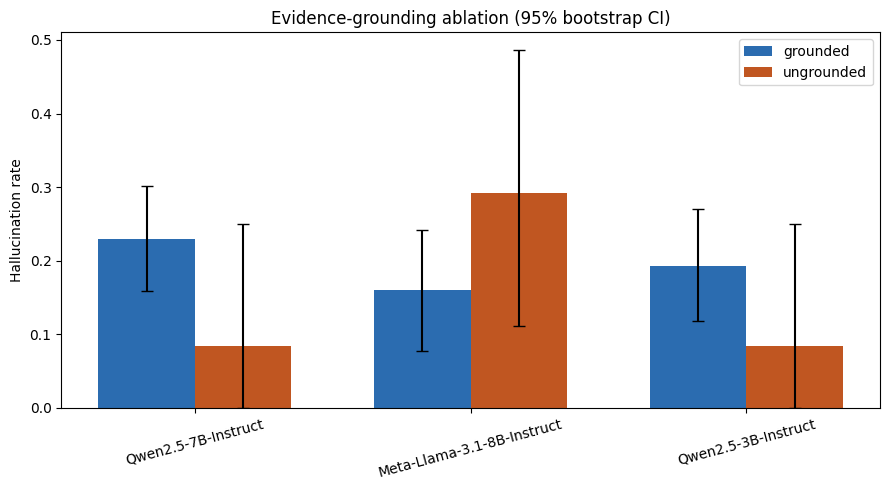

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(MODELS_TO_COMPARE))
width = 0.35

for offset, condition, color in [(-width/2, 'grounded', '#2b6cb0'), (width/2, 'ungrounded', '#c05621')]:
    means, los, his = [], [], []
    for model in MODELS_TO_COMPARE:
        vals = combined_eval_df[(combined_eval_df.model == model) & (combined_eval_df.condition == condition)]['hallucination_rate']
        m, lo, hi = bootstrap_ci(vals)
        means.append(m); los.append(m - lo); his.append(hi - m)
    ax.bar(x + offset, means, width, yerr=[los, his], capsize=4, label=condition, color=color)

ax.set_xticks(x)
ax.set_xticklabels([m.split('/')[-1] for m in MODELS_TO_COMPARE], rotation=15)
ax.set_ylabel('Hallucination rate')
ax.set_title('Evidence-grounding ablation (95% bootstrap CI)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_ablation_hallucination.png'), dpi=150)
plt.show()

## 9. Save everything for the paper / write-up

In [17]:
combined_eval_df_save = combined_eval_df.copy()
combined_eval_df_save['hallucinated_values'] = combined_eval_df_save['hallucinated_values'].apply(lambda x: pyjson.dumps(x) if isinstance(x, list) else x)
combined_eval_df_save.to_csv(os.path.join(OUTPUT_DIR, 'llm_explanations_combined_with_ablation.csv'), index=False)

print('Saved:')
print(' -', os.path.join(OUTPUT_DIR, 'llm_explanations_combined_with_ablation.csv'), '(grounded pilot + top-up + ungrounded ablation)')
print(' -', os.path.join(FIG_DIR, 'table16_ablation_significance.csv'))
print(' -', os.path.join(FIG_DIR, 'table17_pairwise_model_comparison.csv'))
print(' -', os.path.join(FIG_DIR, 'fig_ablation_hallucination.png'))
print(' - human_eval_annotator_A.csv / _B.csv (send these out), and table18 once returned')

Saved:
 - /content/drive/MyDrive/My Work/Research/Medical_sector/Dengue/dataset/processed/llm_explanations_combined_with_ablation.csv (grounded pilot + top-up + ungrounded ablation)
 - /content/drive/MyDrive/My Work/Research/Medical_sector/Dengue/dataset/figures/table16_ablation_significance.csv
 - /content/drive/MyDrive/My Work/Research/Medical_sector/Dengue/dataset/figures/table17_pairwise_model_comparison.csv
 - /content/drive/MyDrive/My Work/Research/Medical_sector/Dengue/dataset/figures/fig_ablation_hallucination.png
 - human_eval_annotator_A.csv / _B.csv (send these out), and table18 once returned
